### Explicación del script ETL.py (Extracción y Limpieza de Datos)

Este archivo es el encargado de la primera fase del proyecto: ingerir los datos crudos, evaluar su calidad y aplicar las transformaciones necesarias para tener una base sólida y confiable. Está estructurado en dos etapas principales:

- Etapa 1: Análisis y Calidad de Datos

Inspección Estructural (Eu): La función etapa_eu_calidad_datos se encarga de leer el archivo CSV original. Su objetivo es generar un diagnóstico rápido utilizando funciones de Pandas como .head(), .info(), y .describe(). Esto nos permite conocer el volumen de los datos (filas y columnas), los tipos de datos detectados y estadísticas descriptivas iniciales.

Detección de Anomalías (Jonathan): La función etapa_jonathan_calidad_datos complementa el análisis buscando registros duplicados exactos e imprimiendo el conteo de valores de columnas categóricas clave. Esto es vital para identificar inconsistencias tipográficas (ej. variaciones en mayúsculas/minúsculas o espacios adicionales) antes de limpiar.

- Etapa 2: Limpieza de Datos

Transformación (Eu): A través de etapa_eu_limpieza, se ejecutan las acciones correctivas. Primero se eliminan los duplicados detectados. Luego, se itera sobre todas las columnas de texto aplicando .str.strip() para eliminar espacios en blanco accidentales al inicio o final de las palabras, estandarizando así las categorías.

Validación (Jonathan): Finalmente, etapa_jonathan_validacion_final actúa como un control de calidad. Compara la cantidad de registros y columnas del dataset original contra el dataset procesado para asegurar que no hubo pérdida crítica de información durante la limpieza.

Salida: El script concluye exportando el resultado como dataset_limpio.csv, el cual servirá como base para el modelado de datos.



### Explicación del script star_schema.py (Modelado de Datos)

Una vez que los datos están limpios, este script transforma la estructura de un archivo plano a un modelo analítico de estrella (Star Schema). Este modelo divide la información en "Dimensiones" (tablas de catálogo) y una "Tabla de Hechos" central, optimizando la base para consultas en herramientas de Business Intelligence.

- Etapa 3 y 4: Construcción de Dimensiones
El trabajo se dividió temáticamente para extraer los valores únicos de cada categoría, generarles un identificador numérico (ID) y exportarlos como tablas independientes:

Dimensiones Demográficas (Eu): Crea catálogos para los perfiles de los encuestados (Dim_Edad, Dim_Genero, Dim_Departamento, Dim_Municipio, Dim_Ocupacion).

Dimensiones de Marketing (Jonathan): Crea catálogos para los motivadores de compra (Dim_Seleccion, Dim_Jugador, Dim_Promocion).

Dimensiones de Consumo y Tiempo (Nicole): Genera catálogos de los hábitos (Dim_Frecuencia, Dim_LugarCompra, etc.) y la tabla Dim_Tiempo para análisis cronológicos.

Construcción de la Tabla de Hechos (Nicole)
La función construir_tabla_hechos es el núcleo del modelo. Toma el dataset_limpio.csv y realiza uniones (usando merge o "JOINs") con cada una de las tablas dimensionales creadas anteriormente. El objetivo es reemplazar los textos descriptivos por sus respectivos IDs numéricos.

Salida: El resultado es Fact_Encuestas.csv, una tabla transaccional altamente eficiente compuesta casi en su totalidad por llaves foráneas numéricas y métricas directas (como el precio aceptado).



In [ ]:
import pandas as pd
from IPython.display import display, HTML
import os

# Ruta donde se encuentran las tablas limpias (Ajusta la ruta según tus carpetas)
ruta_tablas = "../3_Tablas_Limpias/" 

# Diccionario con el archivo y su título con iconos
tablas_nombradas = {
    "1. Dimensión Edad": "Dim_Edad.csv",
    "2. Dimensión Género": "Dim_Genero.csv",
    "3. Dimensión Departamento": "Dim_Departamento.csv",
    "4. Dimensión Municipio": "Dim_Municipio.csv",
    "5. Dimensión Ocupación": "Dim_Ocupacion.csv",
    "6. Dimensión Frecuencia": "Dim_Frecuencia.csv",
    "7. Dimensión Lugar de Compra": "Dim_LugarCompra.csv",
    "8. Dimensión Compañía Partidos": "Dim_CompaniaPartidos.csv",
    "9. Dimensión Snacks": "Dim_Snacks.csv",
    "10. Dimensión Sabor": "Dim_Sabor.csv",
    "11. Dimensión Presentación": "Dim_Presentacion.csv",
    "12. Dimensión Tiempo": "Dim_Tiempo.csv",
    "13. Dimensión Selección": "Dim_Seleccion.csv",
    "14. Dimensión Jugador": "Dim_Jugador.csv",
    "15. Dimensión Promoción": "Dim_Promocion.csv",
    "16. TABLA DE HECHOS CENTRAL (Fact_Encuestas)": "Fact_Encuestas.csv"
}

# CSS para darle diseño profesional a las tablas de Pandas
estilos_tabla = [
    # Diseño para los encabezados (Nombres de las columnas)
    {'selector': 'th', 
     'props': [('background-color', '#1F618D'), 
               ('color', 'white'), 
               ('font-family', 'Segoe UI, Arial, sans-serif'),
               ('font-weight', 'bold'),
               ('text-align', 'center'), 
               ('padding', '10px 15px'),
               ('border', '1px solid #1A5276')]},
    # Diseño para las celdas de datos
    {'selector': 'td', 
     'props': [('font-family', 'Segoe UI, Arial, sans-serif'), 
               ('padding', '8px 15px'), 
               ('text-align', 'center'), 
               ('border', '1px solid #D6EAF8')]},
    # Efecto Hover (Cambia de color al pasar el mouse por encima de la fila)
    {'selector': 'tr:hover', 
     'props': [('background-color', '#EBF5FB')]}
]

# Iterar sobre el diccionario para mostrar el título estilizado y la tabla
for titulo, archivo in tablas_nombradas.items():
    ruta_archivo = os.path.join(ruta_tablas, archivo)
    
    if os.path.exists(ruta_archivo):
        # 1. TÍTULO DE LA TABLA (Diseño tipo Tarjeta)
        display(HTML(f"""
        <div style='background: linear-gradient(90deg, #EBF5FB 0%, #ffffff 100%); 
                    padding: 12px 15px; 
                    border-left: 6px solid #2980B9; 
                    border-radius: 4px;
                    margin-top: 30px; 
                    margin-bottom: 15px;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.05);'>
            <h3 style='margin: 0; color: #1A5276; font-family: Segoe UI, Arial, sans-serif;'>
                {titulo} <span style='font-size: 14px; color: #7F8C8D; font-weight: normal;'>(Archivo: {archivo})</span>
            </h3>
        </div>
        """))
        
        # 2. LECTURA Y ESTILIZADO DE LA TABLA PANDAS
        df_temp = pd.read_csv(ruta_archivo)
        
        # Aplicamos el CSS, ocultamos el índice (0,1,2,3...) y mostramos los primeros 5 renglones
        tabla_estilizada = (df_temp.head(5)
                            .style.set_table_styles(estilos_tabla)
                            .hide(axis='index')) # Esto es clave para que se vea más limpia
        
        display(tabla_estilizada)
        
        # 3. PIE DE TABLA (Resumen de registros)
        display(HTML(f"""
        <p style='color: #7F8C8D; font-size: 12px; font-family: Segoe UI, Arial, sans-serif; margin-top: 5px; margin-bottom: 30px;'>
            <em>✓ La tabla completa contiene <b>{len(df_temp)} registros únicos</b> listos para integrarse al Data Warehouse.</em>
        </p>
        """))
        
    else:
        # Mensaje de error estilizado por si falta algún CSV
        display(HTML(f"""
        <div style='background-color: #FDEDEC; padding: 10px; border-left: 5px solid #E74C3C; margin-top: 20px;'>
            <p style='margin: 0; color: #C0392B;'><b>Alerta de Archivo:</b> No se encontró la tabla <code>{archivo}</code> en la ruta especificada.</p>
        </div>
        """))

### 1. Tabla: Dim_Edad (Dimensión de Edad)

La tabla *Dim_Edad* es el catálogo central diseñado para segmentar generacionalmente a la base de consumidores. En la arquitectura del *Star Schema, esta tabla aísla la variable de la edad asignándole una llave primaria (ID_Edad) que se conecta con la tabla de hechos. Esto evita procesar largas cadenas de texto repetitivas (como *"18 - 24 años" o "Menos de 18 años") miles de veces en la memoria, optimizando el rendimiento del modelo *Zero-ETL*.

Desde la perspectiva de negocio, esta dimensión es el pilar para definir el tono comunicacional y el poder adquisitivo del público objetivo. Entender la distribución por edades permite a la marca saber si la campaña debe enfocarse en la *Generación Z* (quienes suelen consumir contenido rápido en TikTok o Instagram y buscan snacks individuales económicos) o en la *Generación X y Millennials* mayores (quienes tienen un mayor poder adquisitivo, compran formatos familiares para compartir en casa y consumen publicidad en televisión tradicional). Al cruzar esta tabla con las preferencias de marketing, el equipo puede diseñar estrategias altamente personalizadas que maximicen el *Retorno de Inversión (ROI)* publicitario durante la fiebre mundialista.

### 2. Tabla: Dim_Genero (Dimensión de Género)

La tabla *Dim_Genero* estandariza la identidad demográfica de los encuestados a través de su identificador único (*ID_Genero) asociado a los valores categóricos (*Masculino, Femenino, Prefiero no indicar). La creación de esta tabla fue posible gracias a las fases previas de limpieza de datos lideradas por Eu, donde se eliminaron inconsistencias tipográficas para asegurar que el catálogo fuera perfectamente único y agrupara los datos de forma exacta, sin bifurcaciones erróneas.

En el ámbito comercial para la campaña del Mundial 2026, esta dimensión juega un papel crítico para garantizar una comunicación inclusiva y precisa. Históricamente, el marketing deportivo tenía sesgos hacia ciertos géneros, pero el análisis de esta tabla permite a la empresa basar sus decisiones en datos empíricos reales en lugar de suposiciones. Si el cruce de datos demuestra una distribución equitativa de interés por los snacks temáticos, la marca puede diseñar empaques neutrales y campañas universales. Además, permite descubrir nichos ocultos; por ejemplo, si un género específico muestra mayor disposición a pagar por tarjetas coleccionables, las activaciones en puntos de venta pueden ajustarse para captar directamente la atención de ese segmento particular.

### 3. Tabla: Dim_Departamento (Dimensión de Departamento)

La tabla *Dim_Departamento* representa la segmentación geográfica a nivel macro. Este catálogo asigna un *ID_Departamento* a cada uno de los departamentos de Guatemala presentes en la muestra de los 2,500 encuestados. Estructuralmente, separar la ubicación en su propia dimensión facilita enormemente la creación de mapas coropléticos (mapas de calor geográficos) en herramientas de visualización como Power BI, ya que el motor analítico solo necesita leer el catálogo una vez para renderizar las zonas.

A nivel de estrategia empresarial, esta tabla es el mapa de ruta para el equipo de *Logística y Cadena de Suministro*. Lanzar una edición limitada de snacks para el Mundial conlleva un alto riesgo de quiebre de stock si el producto no se distribuye correctamente. Esta dimensión revela exactamente dónde reside la mayor concentración de la demanda potencial. Si los datos muestran que el 70% del interés proviene de los departamentos de Guatemala y Quetzaltenango, la empresa sabe que debe priorizar el envío de inventario pesado hacia esos centros de distribución principales, optimizando los costos de transporte y asegurando que las estanterías de los supermercados siempre tengan el producto disponible durante los partidos importantes.

### 4. Tabla: Dim_Municipio (Dimensión de Municipio)

Complementando la visión macro, la tabla *Dim_Municipio* ofrece la granularidad geográfica a nivel micro. Este catálogo (*ID_Municipio* y *Municipio*) desciende un nivel más en la jerarquía espacial, permitiendo aislar ciudades, cabeceras municipales o localidades específicas. En el esquema de estrella, mantener los municipios separados en su propia tabla dimensional permite hacer filtros dinámicos muy rápidos sin sobrecargar la tabla de transacciones central.

Comercialmente, esta tabla es una mina de oro para las estrategias de marketing conocidas como *BTL (Below The Line)* y *Trade Marketing. Mientras que los departamentos dictan la logística mayorista, los municipios dictan las activaciones en campo. Si la marca planea hacer eventos físicos como instalar pantallas gigantes en plazas, llevar edecanes a supermercados locales o regalar muestras gratis de los nuevos sabores mundialistas, esta dimensión indica exactamente en qué municipios se debe invertir ese presupuesto táctico. Es la herramienta perfecta para la táctica de **última milla*, permitiendo que los promotores de la marca ataquen directamente las zonas con mayor densidad de clientes potenciales que mostraron una alta disposición de pago.

### 5. Tabla: Dim_Ocupacion (Dimensión de Ocupación)

La tabla *Dim_Ocupacion* clasifica el estado laboral o profesional de los encuestados (Estudiante, Profesional independiente, Empleado, Jubilado, entre otros), otorgándole a cada categoría su respectivo *ID_Ocupacion*. Esta fue una de las tablas que requirió mayor limpieza previa por parte del equipo para unificar criterios. Analíticamente, es una dimensión socioeconómica que ayuda a perfilar el estilo de vida del consumidor de manera mucho más profunda que la edad por sí sola.

El valor de esta tabla para el negocio radica en la predicción del comportamiento de compra y la disponibilidad de tiempo. El Mundial 2026 tendrá horarios de partidos que inevitablemente se cruzarán con horarios laborales o de estudio. La ocupación es un indicador indirecto del poder adquisitivo y de los momentos de consumo: un *Estudiante* podría buscar promociones agresivas (2x1) y consumir el producto en reuniones por la tarde, mientras que un *Profesional* o *Empresario* podría tener un mayor ticket de compra para formatos premium de fin de semana. Cruzar esta dimensión con el lugar de compra y el gasto estimado le permite a la marca afinar sus estrategias de *pricing* (fijación de precios) y adaptar sus ofertas al bolsillo y rutina de cada segmento laboral.

### 6. Tabla: Dim_Frecuencia (Dimensión de Frecuencia de Consumo)

La tabla *Dim_Frecuencia* aísla y estandariza los hábitos de compra repetitiva de los consumidores ("Diario", "1 a 2 veces por semana", "Rara vez", entre otros). En el modelo *Star Schema, esta dimensión permite reemplazar largas descripciones de texto por un simple **ID_Frecuencia*, optimizando el espacio de almacenamiento y acelerando las consultas cuando se agrupan grandes volúmenes de datos.

Desde la óptica de *Business Intelligence, esta tabla es el pilar para entender la rotación de inventario y la lealtad del cliente (Customer Lifetime Value*). Conocer con qué frecuencia el usuario guatemalteco compra snacks permite al equipo comercial proyectar el volumen de ventas esperado durante el mes que dura el Mundial. Si la mayoría de los encuestados indica un consumo semanal o diario, la marca sabe que puede implementar estrategias de retención agresivas, como álbumes o tarjetas coleccionables que fomenten la recompra constante. Si el consumo es esporádico, la estrategia publicitaria deberá enfocarse en compras impulsivas de una sola vez durante los partidos clave.

### 7. Tabla: Dim_LugarCompra (Dimensión de Lugar de Compra)

El catálogo *Dim_LugarCompra* agrupa los canales físicos y digitales donde el consumidor prefiere adquirir el producto ("Supermercados", "Tiendas de barrio", "Aplicación de delivery", entre otros). Al estandarizar estos valores bajo un *ID_LugarCompra*, el equipo de analítica elimina el riesgo de tener categorías duplicadas por errores de escritura, asegurando agrupamientos perfectos en las visualizaciones de datos.

Comercialmente, esta dimensión define la estrategia de distribución (*Trade Marketing*). Para el éxito de una edición limitada del Mundial, el producto debe estar exactamente donde el cliente va a buscarlo. Si los datos demuestran que las tiendas de barrio dominan la preferencia, la marca debe enfocar su presupuesto en material POP (pósteres, colgantes) para estos pequeños comercios y asegurar rutas de distribución capilar. Si los supermercados o aplicaciones de entrega tienen mayor peso, el presupuesto debe redirigirse a banners digitales y cabeceras de góndola llamativas en los principales puntos de venta.

### 8. Tabla: Dim_CompaniaPartidos (Dimensión de Compañía)

La tabla *Dim_CompaniaPartidos* cataloga el entorno social del encuestado al momento de ver un partido de fútbol ("Solo", "Con amigos", "Con familia", entre otros). Técnicamente, es una dimensión pequeña pero estratégica para cruzarla con los tamaños de empaque y generar análisis combinados dentro de la tabla de hechos.

A nivel de negocio, el fútbol es un evento eminentemente social y esta tabla revela el contexto real de consumo. Entender si el cliente guatemalteco ve el Mundial en grupos grandes o en solitario determina qué formato de producto tendrá mayor aceptación. Si el consumo con amigos y familia predomina, la campaña debe centrar su mensaje en el concepto de compartir la pasión por el fútbol, asociando el snack a experiencias grupales. Esto también justifica promociones como *"Arma tu combo mundialista"* y ayuda a estimar un ticket promedio de compra más elevado.

### 9. Tabla: Dim_Snacks (Dimensión de Snacks Actuales)

La dimensión *Dim_Snacks* actúa como el catálogo de productos preferidos de la marca, unificando los nombres de los snacks seleccionados por los consumidores. Esta tabla requirió un proceso especial de separación y normalización, ya que los encuestados podían elegir múltiples opciones simultáneamente. Al consolidar los productos en un catálogo único, se mantienen las buenas prácticas de diseño dimensional y se evita la duplicidad de registros.

Estratégicamente, esta dimensión mide la afinidad y el posicionamiento actual del portafolio de productos. Antes de lanzar una edición especial para el Mundial 2026, la empresa necesita identificar cuál de sus productos estrella posee la mayor aceptación entre los consumidores. El snack que lidere este catálogo será el candidato ideal para incorporar diseños temáticos, promociones exclusivas o colaboraciones con figuras deportivas, ya que cuenta con una base sólida de consumidores fieles que garantiza un volumen mínimo de ventas.

### 10. Tabla: Dim_Sabor (Dimensión de Perfil de Sabor)

El catálogo *Dim_Sabor* estandariza las preferencias gustativas del mercado, clasificando opciones como "Picante", "Salado", "Dulce" o "Queso". Dentro del esquema relacional, esta dimensión facilita el análisis de preferencias de sabor al cruzarlas con variables demográficas, geográficas y de comportamiento mediante el *ID_Sabor*.

Para el departamento de *Investigación y Desarrollo (I+D)*, esta tabla representa una fuente estratégica de información. Lanzar una edición especial para el Mundial no solo implica modificar el empaque, sino también evaluar posibles sabores de temporada. Esta dimensión permite identificar qué perfiles gustativos presentan mayor probabilidad de éxito en el mercado. Si existe una marcada preferencia por los sabores picantes, la empresa puede justificar el lanzamiento de una edición temática orientada a ese segmento. Asimismo, el cruce con variables como edad o ubicación geográfica permite desarrollar líneas de productos diferenciadas para distintos públicos.

### 11. Tabla: Dim_Presentacion (Dimensión de Presentación/Empaque)

La dimensión *Dim_Presentacion* clasifica el formato físico del producto que el consumidor adquiere habitualmente ("Individual", "Familiar", "Megapack", entre otros). Al disponer de una dimensión independiente, el modelo mantiene una estructura limpia y permite realizar análisis específicos relacionados con rentabilidad, volumen y comportamiento de compra.

El valor de esta tabla para las áreas de *Producción* y *Finanzas* es fundamental. La presentación del producto influye directamente en los costos de fabricación, logística y margen de utilidad. Si el análisis revela una preferencia significativa por los empaques familiares durante los partidos, la empresa puede planificar adecuadamente la producción de formatos de mayor tamaño y asegurar la disponibilidad de materiales necesarios. Además, cada presentación posee márgenes de ganancia distintos, por lo que esta dimensión resulta clave para proyectar ingresos y evaluar la rentabilidad esperada de la campaña mundialista.

### 12. Tabla: Dim_Tiempo (Dimensión Cronológica)

La tabla *Dim_Tiempo* almacena y organiza la información temporal asociada a la recolección de datos, permitiendo desglosar atributos como año, mes, día y otros componentes relevantes. En cualquier modelo *Star Schema*, esta dimensión es indispensable para habilitar funcionalidades avanzadas de análisis temporal y seguimiento de tendencias.

Desde una perspectiva analítica, la dimensión de tiempo permite verificar la distribución cronológica de la muestra y detectar posibles sesgos en la recopilación de información. En escenarios empresariales reales, también facilita el monitoreo del comportamiento del mercado conforme se acerca el Mundial, identificando incrementos de interés, picos de demanda y variaciones en las preferencias del consumidor a lo largo del tiempo. Gracias a esta dimensión, las herramientas de inteligencia de negocios pueden generar comparaciones históricas y análisis evolutivos con gran facilidad.

### 13. Tabla: Dim_Seleccion (Dimensión de Selección)

La tabla *Dim_Seleccion* actúa como el catálogo definitivo de las selecciones nacionales de fútbol que los consumidores guatemaltecos planean apoyar durante el Mundial 2026 (ej. Argentina, Brasil, Francia). A nivel de arquitectura de datos, esta dimensión extrae las preferencias del texto crudo y les asigna un identificador único (*ID_Seleccion*), permitiendo que el motor analítico filtre y agrupe rápidamente los datos sin lidiar con errores tipográficos en la tabla central.

Desde la perspectiva de inteligencia de negocios, esta tabla es el mapa de ruta visual para el equipo de Marketing y Diseño de Empaques. La información almacenada aquí dicta directamente qué banderas, colores y escudos deben imprimirse en las bolsas de snacks de edición limitada. Si los datos revelan que el 60% de la muestra apoya a un "Top 3" específico de países, la empresa puede focalizar su presupuesto de producción y empaquetado exclusivamente en esas temáticas, mitigando el enorme riesgo financiero de fabricar mercancía de selecciones con baja afinidad local. Al cruzar esta dimensión con las ventas proyectadas y la geografía, la marca puede incluso enviar lotes de productos temáticos a las regiones donde la afición por ese país es estadísticamente más fuerte.

### 14. Tabla: Dim_Jugador (Dimensión de Jugador)

El catálogo *Dim_Jugador* aísla de manera individual a las estrellas del fútbol mundial que ejercen mayor influencia sobre la decisión de compra del consumidor (ej. Lionel Messi, Kylian Mbappé, Jude Bellingham). Debido a que los encuestados podían seleccionar múltiples jugadores en el formulario, la creación de esta tabla requirió un proceso técnico de desanidamiento (función explode) para garantizar que la base de datos cumpliera con las estrictas reglas de normalización del modelo dimensional, asignando a cada figura un *ID_Jugador* único.

A nivel estratégico, esta dimensión resuelve uno de los dilemas financieros más grandes de la campaña: la inversión en derechos de imagen corporativa. En el marketing deportivo moderno, las marcas personales de los jugadores suelen tener un poder de conversión mayor que las propias selecciones nacionales. Este catálogo permite calcular el *Retorno de Inversión (ROI)* potencial de contratar a un jugador como el "rostro oficial" del producto. Si al cruzar esta dimensión con la tabla de hechos descubrimos que los fans de un jugador específico están dispuestos a pagar un ticket mucho más alto por el snack, la empresa puede justificar el elevado costo de su licencia, asegurando altos márgenes de ganancia.

### 15. Tabla: Dim_Promocion (Dimensión de Promoción)

La tabla *Dim_Promocion* clasifica y estandariza las mecánicas de enganche publicitario que el consumidor prefiere al interactuar con productos de temporada (ej. Tarjetas Coleccionables, Descuentos Directos, 2x1, Sorteos de Viajes). Al convertir estas estrategias en una dimensión estructurada mediante un *ID_Promocion*, el modelo de Business Intelligence puede evaluar rápidamente qué tipo de incentivo genera la mayor intención teórica de compra dentro del esquema de estrella.

Para el departamento Comercial y de Trade Marketing, esta tabla define la estrategia de retención y el *Customer Lifetime Value (CLV)* durante el corto ciclo de vida del torneo. Si el análisis arroja que los "Coleccionables físicos" son la promoción ganadora, la marca tiene luz verde para integrar elementos de gamificación (como tazos o estampas exclusivas dentro de la bolsa). Esta táctica psicológica obliga al consumidor a la recompra constante para completar una colección, asegurando un volumen de ventas sostenido durante todo el mes que dura el Mundial. Por el contrario, si la preferencia se inclina hacia los "Descuentos directos", la empresa sabrá que está compitiendo por precio y deberá ajustar sus utilidades para ganar volumen en los estantes.

### 16. Tabla: Fact_Encuestas (Tabla de Hechos Central)

La *Fact_Encuestas* constituye el núcleo del modelo dimensional y la pieza central del *Star Schema. Esta tabla contiene principalmente las llaves foráneas provenientes de todas las dimensiones (ID_Edad, **ID_Genero, **ID_Departamento, **ID_Sabor, **ID_Frecuencia*, entre otras), junto con las métricas cuantitativas relevantes, como el presupuesto estimado o el precio considerado adecuado por el consumidor.

Desde la perspectiva tecnológica, este diseño permite que los motores analíticos procesen grandes volúmenes de información de manera eficiente, ya que las operaciones sobre identificadores numéricos son considerablemente más rápidas que sobre cadenas de texto. Desde el punto de vista empresarial, esta tabla es la que hace posible responder preguntas complejas y multidimensionales. Por ejemplo, permite identificar qué grupos demográficos muestran mayor preferencia por determinados sabores, cuáles son los segmentos con mayor disposición de pago o qué regiones presentan el mayor potencial de ventas para una edición especial del Mundial 2026. Gracias a la integración de todas las dimensiones en una única estructura central, la organización puede transformar datos aislados en información estratégica para la toma de decisiones.

In [1]:
import pandas as pd
from IPython.display import display, HTML
import os

# Ruta donde se encuentran las tablas limpias (Ajusta la ruta según tus carpetas)
ruta_tablas = "../3_Tablas_Limpias/" 

# Diccionario con el archivo y su título con iconos
tablas_nombradas = {
    "1. Dimensión Edad": "Dim_Edad.csv",
    "2. Dimensión Género": "Dim_Genero.csv",
    "3. Dimensión Departamento": "Dim_Departamento.csv",
    "4. Dimensión Municipio": "Dim_Municipio.csv",
    "5. Dimensión Ocupación": "Dim_Ocupacion.csv",
    "6. Dimensión Frecuencia": "Dim_Frecuencia.csv",
    "7. Dimensión Lugar de Compra": "Dim_LugarCompra.csv",
    "8. Dimensión Compañía Partidos": "Dim_CompaniaPartidos.csv",
    "9. Dimensión Snacks": "Dim_Snacks.csv",
    "10. Dimensión Sabor": "Dim_Sabor.csv",
    "11. Dimensión Presentación": "Dim_Presentacion.csv",
    "12. Dimensión Tiempo": "Dim_Tiempo.csv",
    "13. Dimensión Selección": "Dim_Seleccion.csv",
    "14. Dimensión Jugador": "Dim_Jugador.csv",
    "15. Dimensión Promoción": "Dim_Promocion.csv",
    "16. TABLA DE HECHOS CENTRAL (Fact_Encuestas)": "Fact_Encuestas.csv"
}

# CSS para darle diseño profesional a las tablas de Pandas
estilos_tabla = [
    # Diseño para los encabezados (Nombres de las columnas)
    {'selector': 'th', 
     'props': [('background-color', '#1F618D'), 
               ('color', 'white'), 
               ('font-family', 'Segoe UI, Arial, sans-serif'),
               ('font-weight', 'bold'),
               ('text-align', 'center'), 
               ('padding', '10px 15px'),
               ('border', '1px solid #1A5276')]},
    # Diseño para las celdas de datos
    {'selector': 'td', 
     'props': [('font-family', 'Segoe UI, Arial, sans-serif'), 
               ('padding', '8px 15px'), 
               ('text-align', 'center'), 
               ('border', '1px solid #D6EAF8')]},
    # Efecto Hover (Cambia de color al pasar el mouse por encima de la fila)
    {'selector': 'tr:hover', 
     'props': [('background-color', '#EBF5FB')]}
]

# Iterar sobre el diccionario para mostrar el título estilizado y la tabla
for titulo, archivo in tablas_nombradas.items():
    ruta_archivo = os.path.join(ruta_tablas, archivo)
    
    if os.path.exists(ruta_archivo):
        # 1. TÍTULO DE LA TABLA (Diseño tipo Tarjeta)
        display(HTML(f"""
        <div style='background: linear-gradient(90deg, #EBF5FB 0%, #ffffff 100%); 
                    padding: 12px 15px; 
                    border-left: 6px solid #2980B9; 
                    border-radius: 4px;
                    margin-top: 30px; 
                    margin-bottom: 15px;
                    box-shadow: 2px 2px 5px rgba(0,0,0,0.05);'>
            <h3 style='margin: 0; color: #1A5276; font-family: Segoe UI, Arial, sans-serif;'>
                {titulo} <span style='font-size: 14px; color: #7F8C8D; font-weight: normal;'>(Archivo: {archivo})</span>
            </h3>
        </div>
        """))
        
        # 2. LECTURA Y ESTILIZADO DE LA TABLA PANDAS
        df_temp = pd.read_csv(ruta_archivo)
        
        # Aplicamos el CSS, ocultamos el índice (0,1,2,3...) y mostramos los primeros 5 renglones
        tabla_estilizada = (df_temp.head(5)
                            .style.set_table_styles(estilos_tabla)
                            .hide(axis='index')) # Esto es clave para que se vea más limpia
        
        display(tabla_estilizada)
        
        # 3. PIE DE TABLA (Resumen de registros)
        display(HTML(f"""
        <p style='color: #7F8C8D; font-size: 12px; font-family: Segoe UI, Arial, sans-serif; margin-top: 5px; margin-bottom: 30px;'>
            <em>✓ La tabla completa contiene <b>{len(df_temp)} registros únicos</b> listos para integrarse al Data Warehouse.</em>
        </p>
        """))
        
    else:
        # Mensaje de error estilizado por si falta algún CSV
        display(HTML(f"""
        <div style='background-color: #FDEDEC; padding: 10px; border-left: 5px solid #E74C3C; margin-top: 20px;'>
            <p style='margin: 0; color: #C0392B;'><b>Alerta de Archivo:</b> No se encontró la tabla <code>{archivo}</code> en la ruta especificada.</p>
        </div>
        """))

ID_Edad,RangoEdad
1,55 años o más
2,18 - 24 años
3,35 - 44 años
4,25 - 34 años
5,Menos de 18 años


ID_Genero,Genero
1,Femenino
2,Masculino
3,Prefiero No Indicarlo


ID_Departamento,Departamento
1,Guatemala
2,Alta Verapaz
3,Quetzaltenango
4,Sacatepéquez
5,Chimaltenango


ID_Municipio,Municipio
1,Santa Catarina Pinula
2,Alta Verapaz
3,San Miguel Petapa
4,Olintepeque
5,Ciudad Vieja


ID_Ocupacion,Ocupacion
1,Jubilado
2,Empresario
3,Estudiante
4,Empleado Privado
5,Comerciante


...

ID_Tiempo,FechaEncuesta
1,2026-04-15
2,2026-01-26
3,2026-04-22
4,2026-01-28
5,2026-03-04


ID_Seleccion,Seleccion
1,Portugal
2,España
3,Inglaterra
4,Estados Unidos
5,Francia


ID_Jugador,Jugador
1,Kylian Mbappé; Cristiano Ronaldo; Neymar Jr.
2,Cristiano Ronaldo; Kylian Mbappé; Christian Pulisic
3,Cristiano Ronaldo; Federico Valverde
4,Vinícius Júnior
5,Kylian Mbappé


ID_Promocion,Tipo_Promocion
1,Sorteo de viajes
2,Producto gratis
3,Descuento directo
4,2x1
5,Tarjetas coleccionables


ID_Encuesta,ID_Edad,ID_Genero,ID_Departamento,ID_Municipio,ID_Ocupacion,ID_Seleccion,ID_Jugador,ID_Promocion,ID_Frecuencia,ID_LugarCompra,ID_CompaniaPartidos,ID_Snack,ID_Sabor,ID_Presentacion,ID_Tiempo,PrecioAdecuado
1,1,1,1,1.000000,1.000000,1,1,1,1,1.000000,1,1,1.000000,1,1,Q10 - Q15
2,2,2,1,1.000000,2.000000,1,2,2,2,2.000000,2,2,2.000000,1,2,Q21 - Q30
3,3,2,2,2.000000,3.000000,2,3,3,1,3.000000,3,3,3.000000,1,3,Q16 - Q20
4,4,1,1,3.000000,4.000000,3,4,4,3,4.000000,2,4,4.000000,1,4,Q16 - Q20
5,4,1,1,3.000000,3.000000,2,5,5,1,5.000000,1,5,5.000000,2,5,Q16 - Q20


### 3. Explicación del script dashboard.py (Métricas y Visualizaciones)

Este último bloque de código se encarga de consumir los datos procesados para generar insights visuales a través de las librerías Matplotlib y Seaborn. Las visualizaciones se guardan automáticamente como imágenes (PNG) para su integración en reportes o dashboards.

- Métricas Demográficas (Eu)
La función generar_graficos_demograficas calcula el KPI principal (total de encuestas) y genera visualizaciones sobre quiénes son los encuestados. Utiliza gráficos de pastel para distribuciones simples (género) y gráficos de barras (verticales y horizontales) ordenados lógicamente para representar la edad y la concentración geográfica (departamentos y top 10 municipios).

- Métricas de Marketing (Jonathan)
La función generar_graficos_marketing visualiza las intenciones de compra y preferencias publicitarias. Un paso clave en este script ocurre antes de graficar: la columna de Jugadores (que contenía múltiples valores separados por punto y coma) se divide y se procesa con la función .explode(). Esto permite separar a los jugadores en filas individuales para que el conteo de popularidad sea exacto.

Se utilizan histogramas para visualizar la distribución del presupuesto (Precio_Aceptado).

Se utilizan gráficos de barras para crear los rankings del Top 10 de Selecciones y Jugadores que más influyen en la compra.

Se utilizan gráficos de dona/pastel y barras para las preferencias de promociones y canales publicitarios.

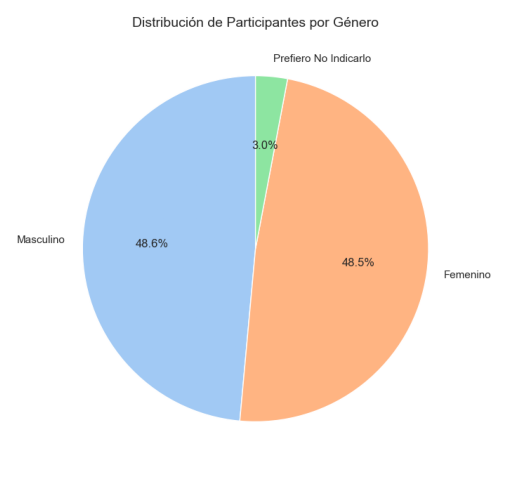

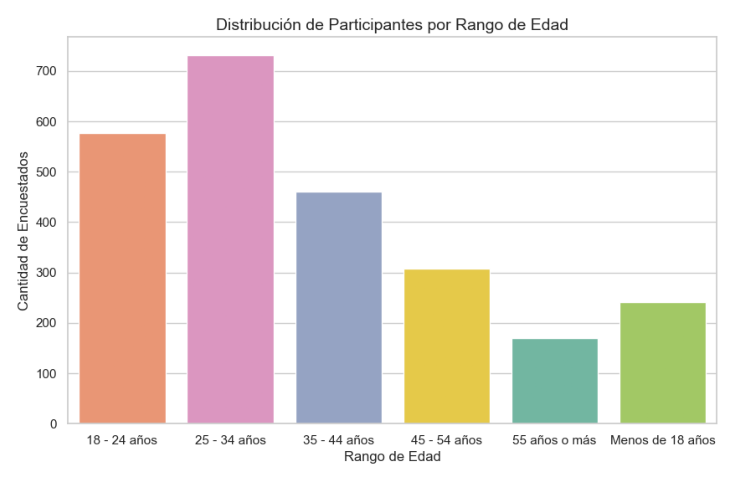

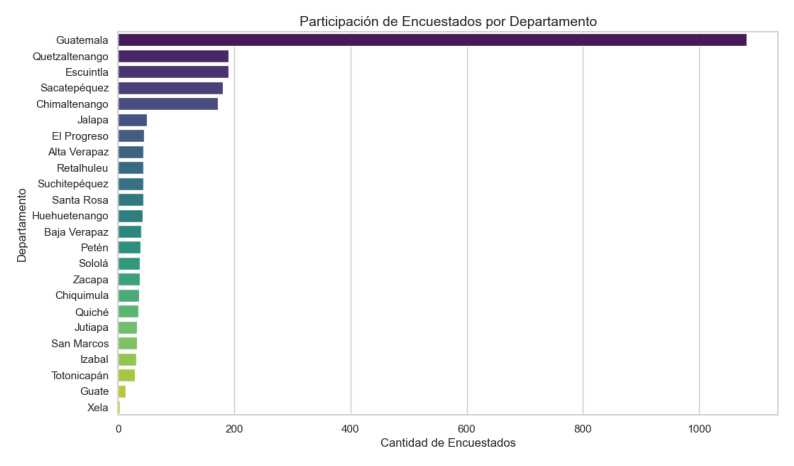

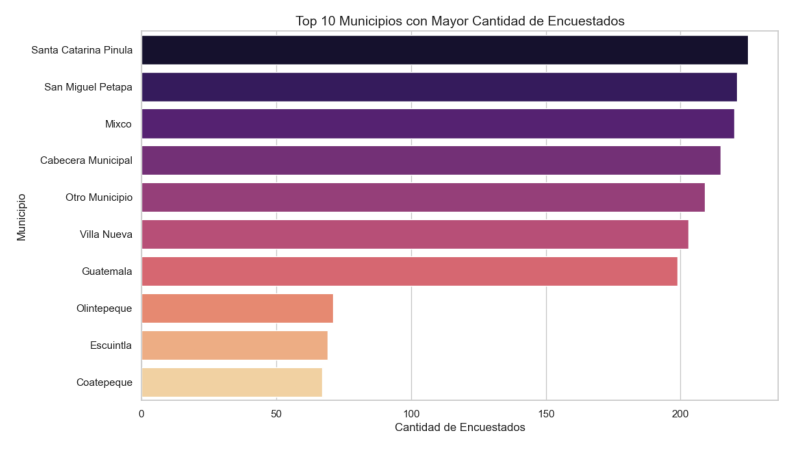

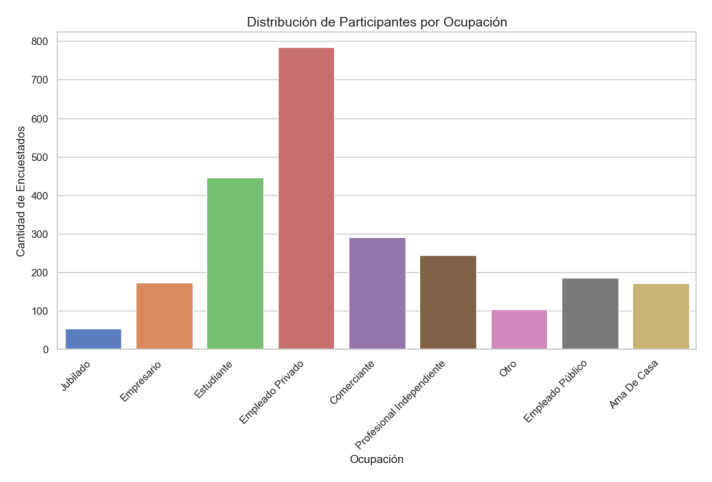

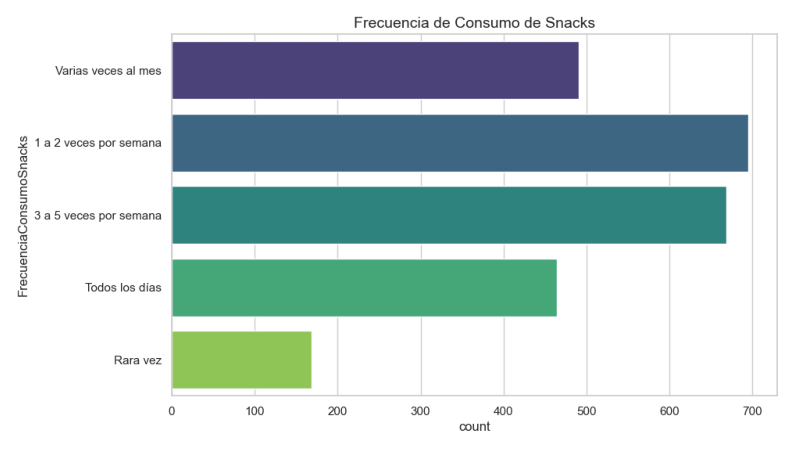

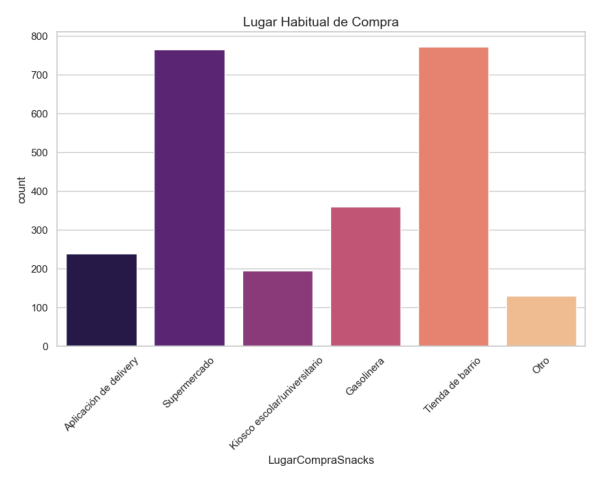

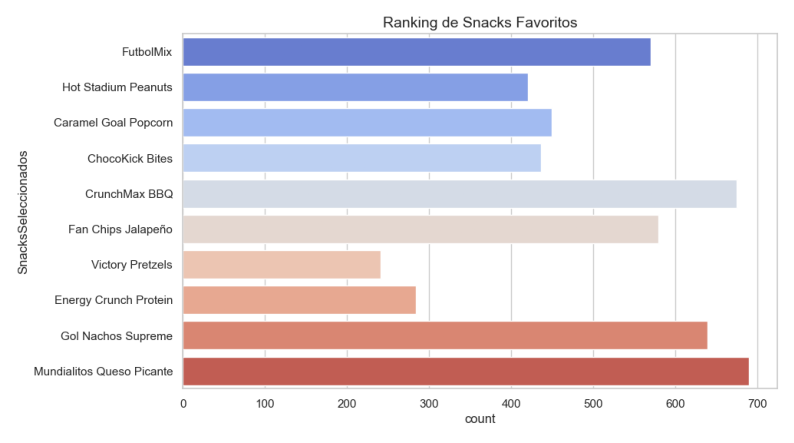

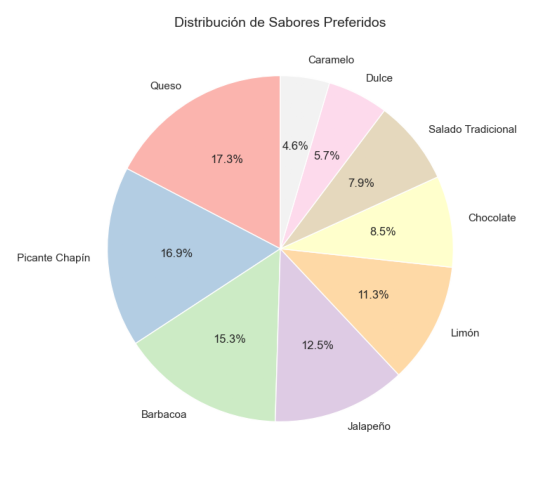

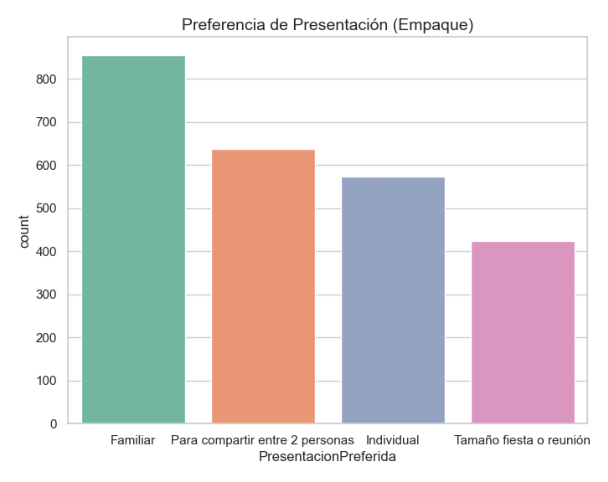

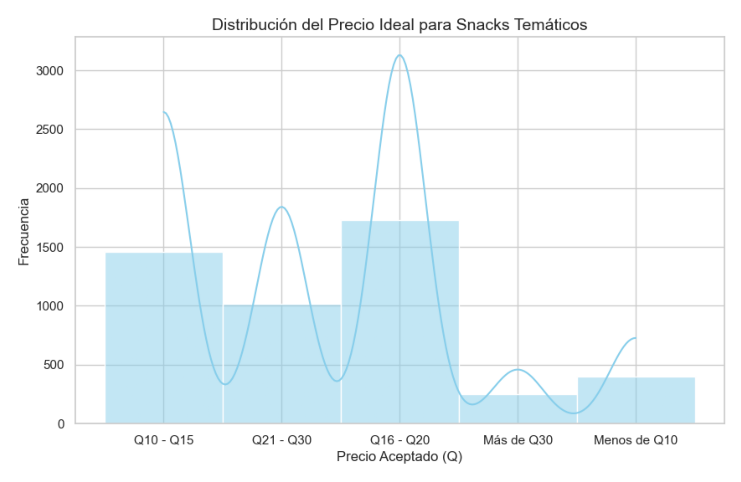

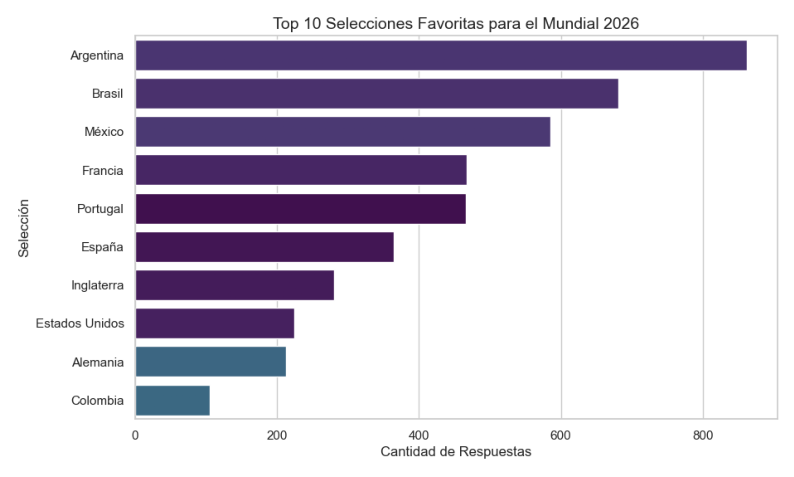

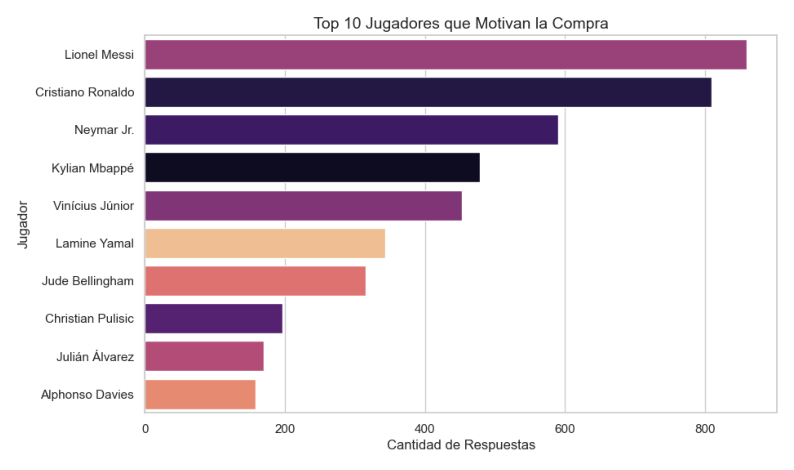

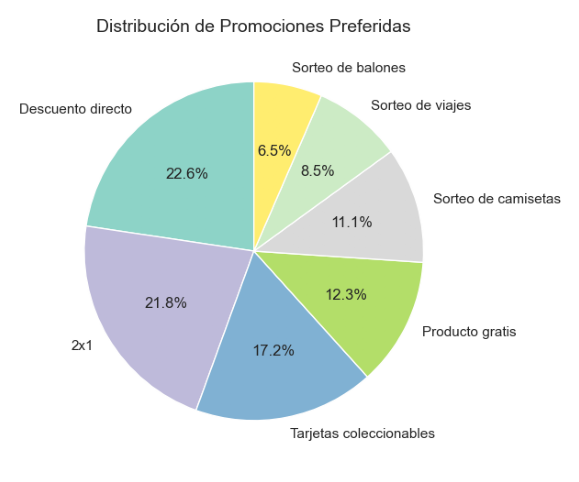

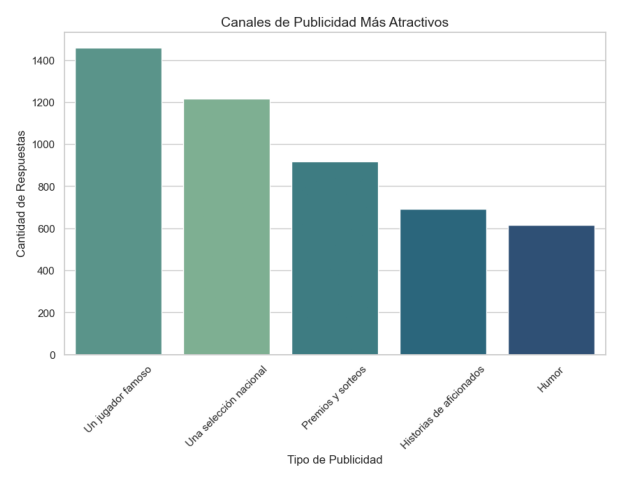

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, HTML
import os

# En un Notebook, usamos os.getcwd() para obtener la carpeta actual
directorio_base = os.getcwd() 

# Si tu notebook está en "4_Codigo_Python" y las fotos en "1_Entregables":
ruta_graficos = os.path.abspath(os.path.join(os.getcwd(), '..', '1_Entregables', 'Graficos'))

# Lista de gráficos
lista_graficos = [
    ("Distribución por Género", "grafico_genero.png"),
    ("Distribución por Rango de Edad", "grafico_edad.png"),
    ("Participación por Departamento", "grafico_departamentos.png"),
    ("Top 10 Municipios", "grafico_municipios.png"),
    ("Distribución por Ocupación", "grafico_ocupacion.png"),
    ("Frecuencia de Consumo", "grafico_frecuencia_consumo.png"),
    ("Lugares de Compra", "grafico_lugar_compra.png"),
    ("Snacks Favoritos", "grafico_snacks.png"),
    ("Distribución de Sabores", "grafico_sabores.png"),
    ("Preferencia de Empaque", "grafico_presentacion.png"),
    ("Precio Ideal de Snacks", "grafico_precio.png"),
    ("Selecciones Favoritas", "grafico_selecciones.png"),
    ("Jugadores Influyentes", "grafico_jugadores.png"),
    ("Promociones Preferidas", "grafico_promociones.png"),
    ("Canales Publicitarios", "grafico_publicidad.png")
]

# Diseño y visualización
for titulo, archivo in lista_graficos:
    ruta_completa = os.path.join(ruta_graficos, archivo)
    
    if os.path.exists(ruta_completa):
        display(HTML(f"""
        <div style='background-color: #f8f9f9; padding: 10px; border-radius: 5px; margin-top: 20px;'>
            <h3 style='color: #2E86C1; margin: 0;'> {titulo}</h3>
            <p style='color: #555; margin: 5px 0 0 0;'>Archivo: <code>{archivo}</code></p>
        </div>
        """))
        
        img = mpimg.imread(ruta_completa)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off') 
        plt.show()
    else:
        # Esto te ayudará a ver dónde está buscando el Notebook realmente si vuelve a fallar
        print(f"No se encontró la imagen en: {ruta_completa}")

## Conclusiones e Interpretación Estratégica de los Datos (Basado en Dashboard de Producción)

### 1. Conclusión sobre la Arquitectura del Sistema Analítico
La transición desde un almacenamiento plano hacia un diseño relacional multidimensional (*Star Schema*) ha demostrado ser una solución óptima para mitigar la redundancia de datos. El aislamiento de las variables demográficas, de mercadeo y de hábitos de consumo en tablas de dimensiones independientes, unidas a través de llaves subrogadas numéricas dentro de la tabla de hechos central `Fact_Encuestas.csv`, reduce la carga computacional en memoria. Esta infraestructura garantiza que las consultas de agregación requeridas para alimentar los módulos del dashboard se ejecuten de manera eficiente, asegurando la escalabilidad del sistema analítico ante incrementos en el volumen de captura.

### 2. Interpretación de Insights y Perfil de Consumidor Integrado

El procesamiento unificado de las fases de consumo, demografía y marketing revela los siguientes hallazgos estratégicos para la campaña de snacks orientada al Mundial 2026:

* **Estrategia de Producto y Empaque (Métricas de Consumo - Nicole):** Los datos procesados a partir del desanidamiento de variables multiselección en el `grafico_snacks.png` permiten identificar con precisión el orden de preferencia de los productos comestibles en el mercado local. Al correlacionar este ranking con el `grafico_sabores.png` (que delimita la participación porcentual de los perfiles de sabor preferidos) y el `grafico_presentacion.png`, la organización cuenta con el fundamento técnico para dimensionar las líneas de producción, priorizando los formatos de empaque específicos que demandan los consumidores.
* **Optimización de Canales de Distribución (Nicole y Eu):** El `grafico_lugar_compra.png` revela los puntos habituales de abastecimiento del mercado. Cruzando este insight demográficamente con la concentración geográfica obtenida en el `grafico_departamentos.png` y el Top 10 detallado del `grafico_municipios.png`, se establece un mapa de distribución logística. Esto permite priorizar el inventario de la edición especial de snacks en los comercios de mayor afluencia dentro de los municipios con mayor densidad de participación registrada.
* **Elasticidad de Precio y Viabilidad Financiera (Marketing - Jonathan):** El análisis de densidad del `precio_aceptado` (representado en el histograma `grafico_precio.png`) establece los umbrales financieros de aceptación por parte del cliente. Al contrastar este presupuesto con el `grafico_ocupacion.png` y el cruce de rangos de edad, se hace evidente la capacidad adquisitiva real de los diferentes segmentos socioeconómicos (como estudiantes o profesionales independientes), blindando la estrategia de fijación de precios contra márgenes de pérdida o sobrevaloración.
* **Activadores de Campaña y Contratos de Licenciamiento (Jonathan):** La segmentación obtenida a través de la separación por filas de variables compuestas en el `grafico_jugadores.png` y el orden de frecuencias del `grafico_selecciones.png` identifican los activos deportivos con mayor retorno de inversión potencial. Integrar estas figuras en las mecánicas comerciales evaluadas en el `grafico_promociones.png` (como empaques coleccionables o incentivos directos) y distribuirlas por los medios del `grafico_publicidad.png` mitiga el riesgo financiero, asegurando que el presupuesto de marketing se asigne a los canales y figuras con mayor tracción demostrada en la muestra.

En conclusión, el pipeline de ingeniería de datos y las visualizaciones integradas en el dashboard mitigan la incertidumbre comercial, transformando un registro crudo de encuestas en un activo de gobernanza empresarial apto para dirigir la toma de decisiones del periodo 2026.